# (28) new code + gaus + logistic + mlp

**Motivation**: host = ```yoru```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from main.config_defaults import default_configs
from figures.convergence import plot_convergence
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## ICLR code: Poisson + vH16

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('Kyoto16-bw', model_type, 'ngd|mlp')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 2/8 * t_train
cfg_vae['latent_act'] = 'logistic'

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

156800

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  659.7 K   |
|     ———     |    ———     |
|    layer    |  659.7 K   |
+-------------+------------+

gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|mlp>
b200-ep800-lr(0.001)_gr(200)_(2025_05_28,21:55)

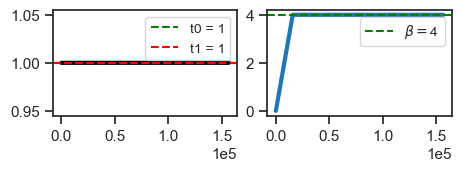

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'_type': 'gaussian', 'latent_act': 'logistic', 't_train': 16, 'kl_beta': 4.0, 'n_latents': 512, 'enc_type': 'ngd',
'dec_type': 'mlp', 'recon_mode': 'mse', 'dataset': 'Kyoto16-bw', 'dataset_name': 'Kyoto16-bw', 'feeder': 
'stationary', 'feeder_cfg': {}, 'input_sz': (1, 16, 16), 'shape': (-1, 1, 16, 16), 'init_dist': 'normal', 
'init_scale': 0.05, 'clamp_vals': {'u': (7.0, 2.0), 'du': (7.0, 3.0), 'dec': 3.45}, 'stochastic': True, 
'fit_dec_var': False, 'fit_prior': True, 'seed': 0, 'track_stats': True, 'base_dir': 
'/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|mlp>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|mlp>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.001, 'epochs': 800, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 796.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_const_portion': 
0.001, 'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.0, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 
'temp_stop': 1.0}

In [7]:
print(tr.model.cfg.clamp_vals)

{'u': (7.0, 2.0), 'du': (7.0, 3.0), 'dec': 3.45}

### Fit model

In [8]:
tr.train('phase9:gaus+logistic+mlp')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 800, avg loss: 6.119: 100%|█████████| 800/800 [3:59:28<00:00, 17.96s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [11]:
# a = 'poisson_vH16-wht_t-10_b-10_k-512_<ngd|lin>'
# b = 'b200-ep300-lr(0.001)_temp(0.05:0.5)_gr(200)_Phase7Test:tuple+Lin_(2025_05_27,19:56)'
# tr, meta = load_model_main(a, b, device=device)
# meta['checkpoint']

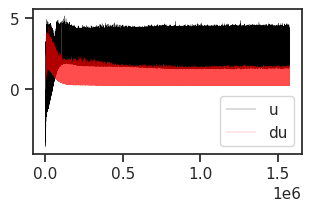

In [14]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

In [15]:
max(tr.model.stats['du_max']), np.quantile(tr.model.stats['du_max'], 0.999)

(4.75985050201416, 3.363843488693234)

In [16]:
max(tr.model.stats['u_max']), np.quantile(tr.model.stats['u_max'], 0.999)

(5.135890483856201, 4.403126881599415)

100%|█████████████████████████████████| 10/10 [00:20<00:00,  2.01s/it]


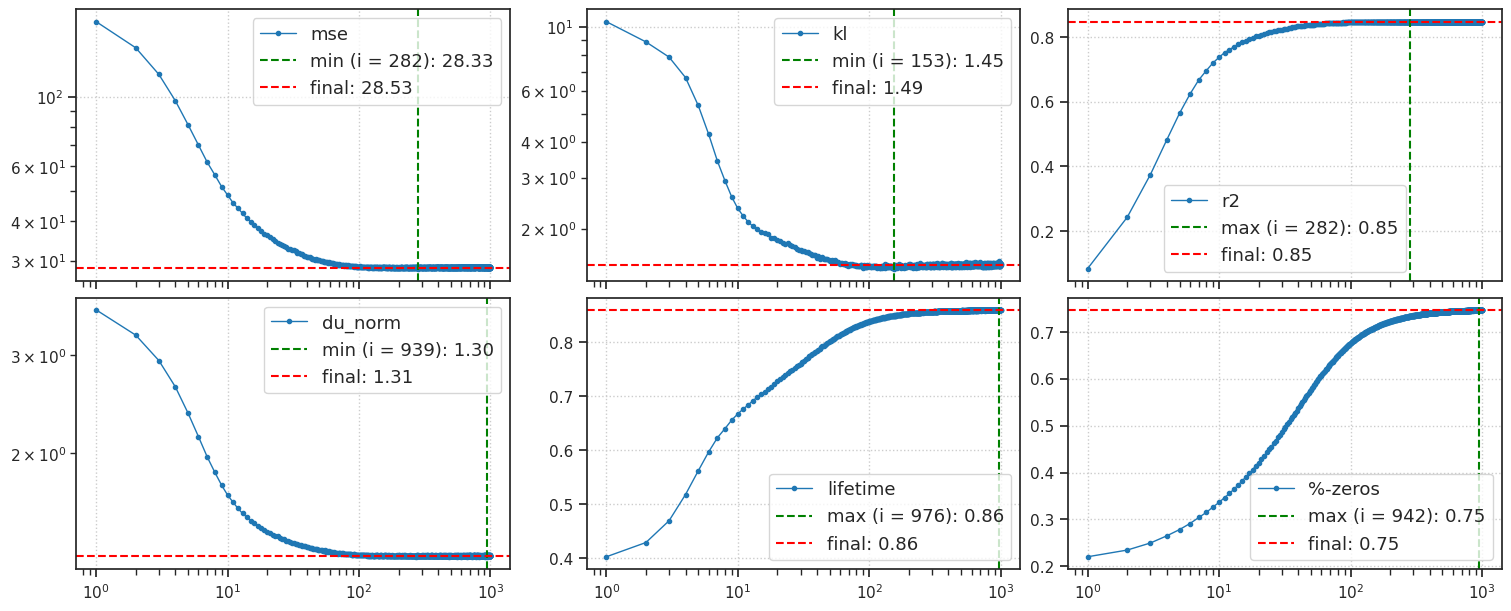

CPU times: user 27.1 s, sys: 728 ms, total: 27.8 s
Wall time: 27.8 s


In [17]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=True,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

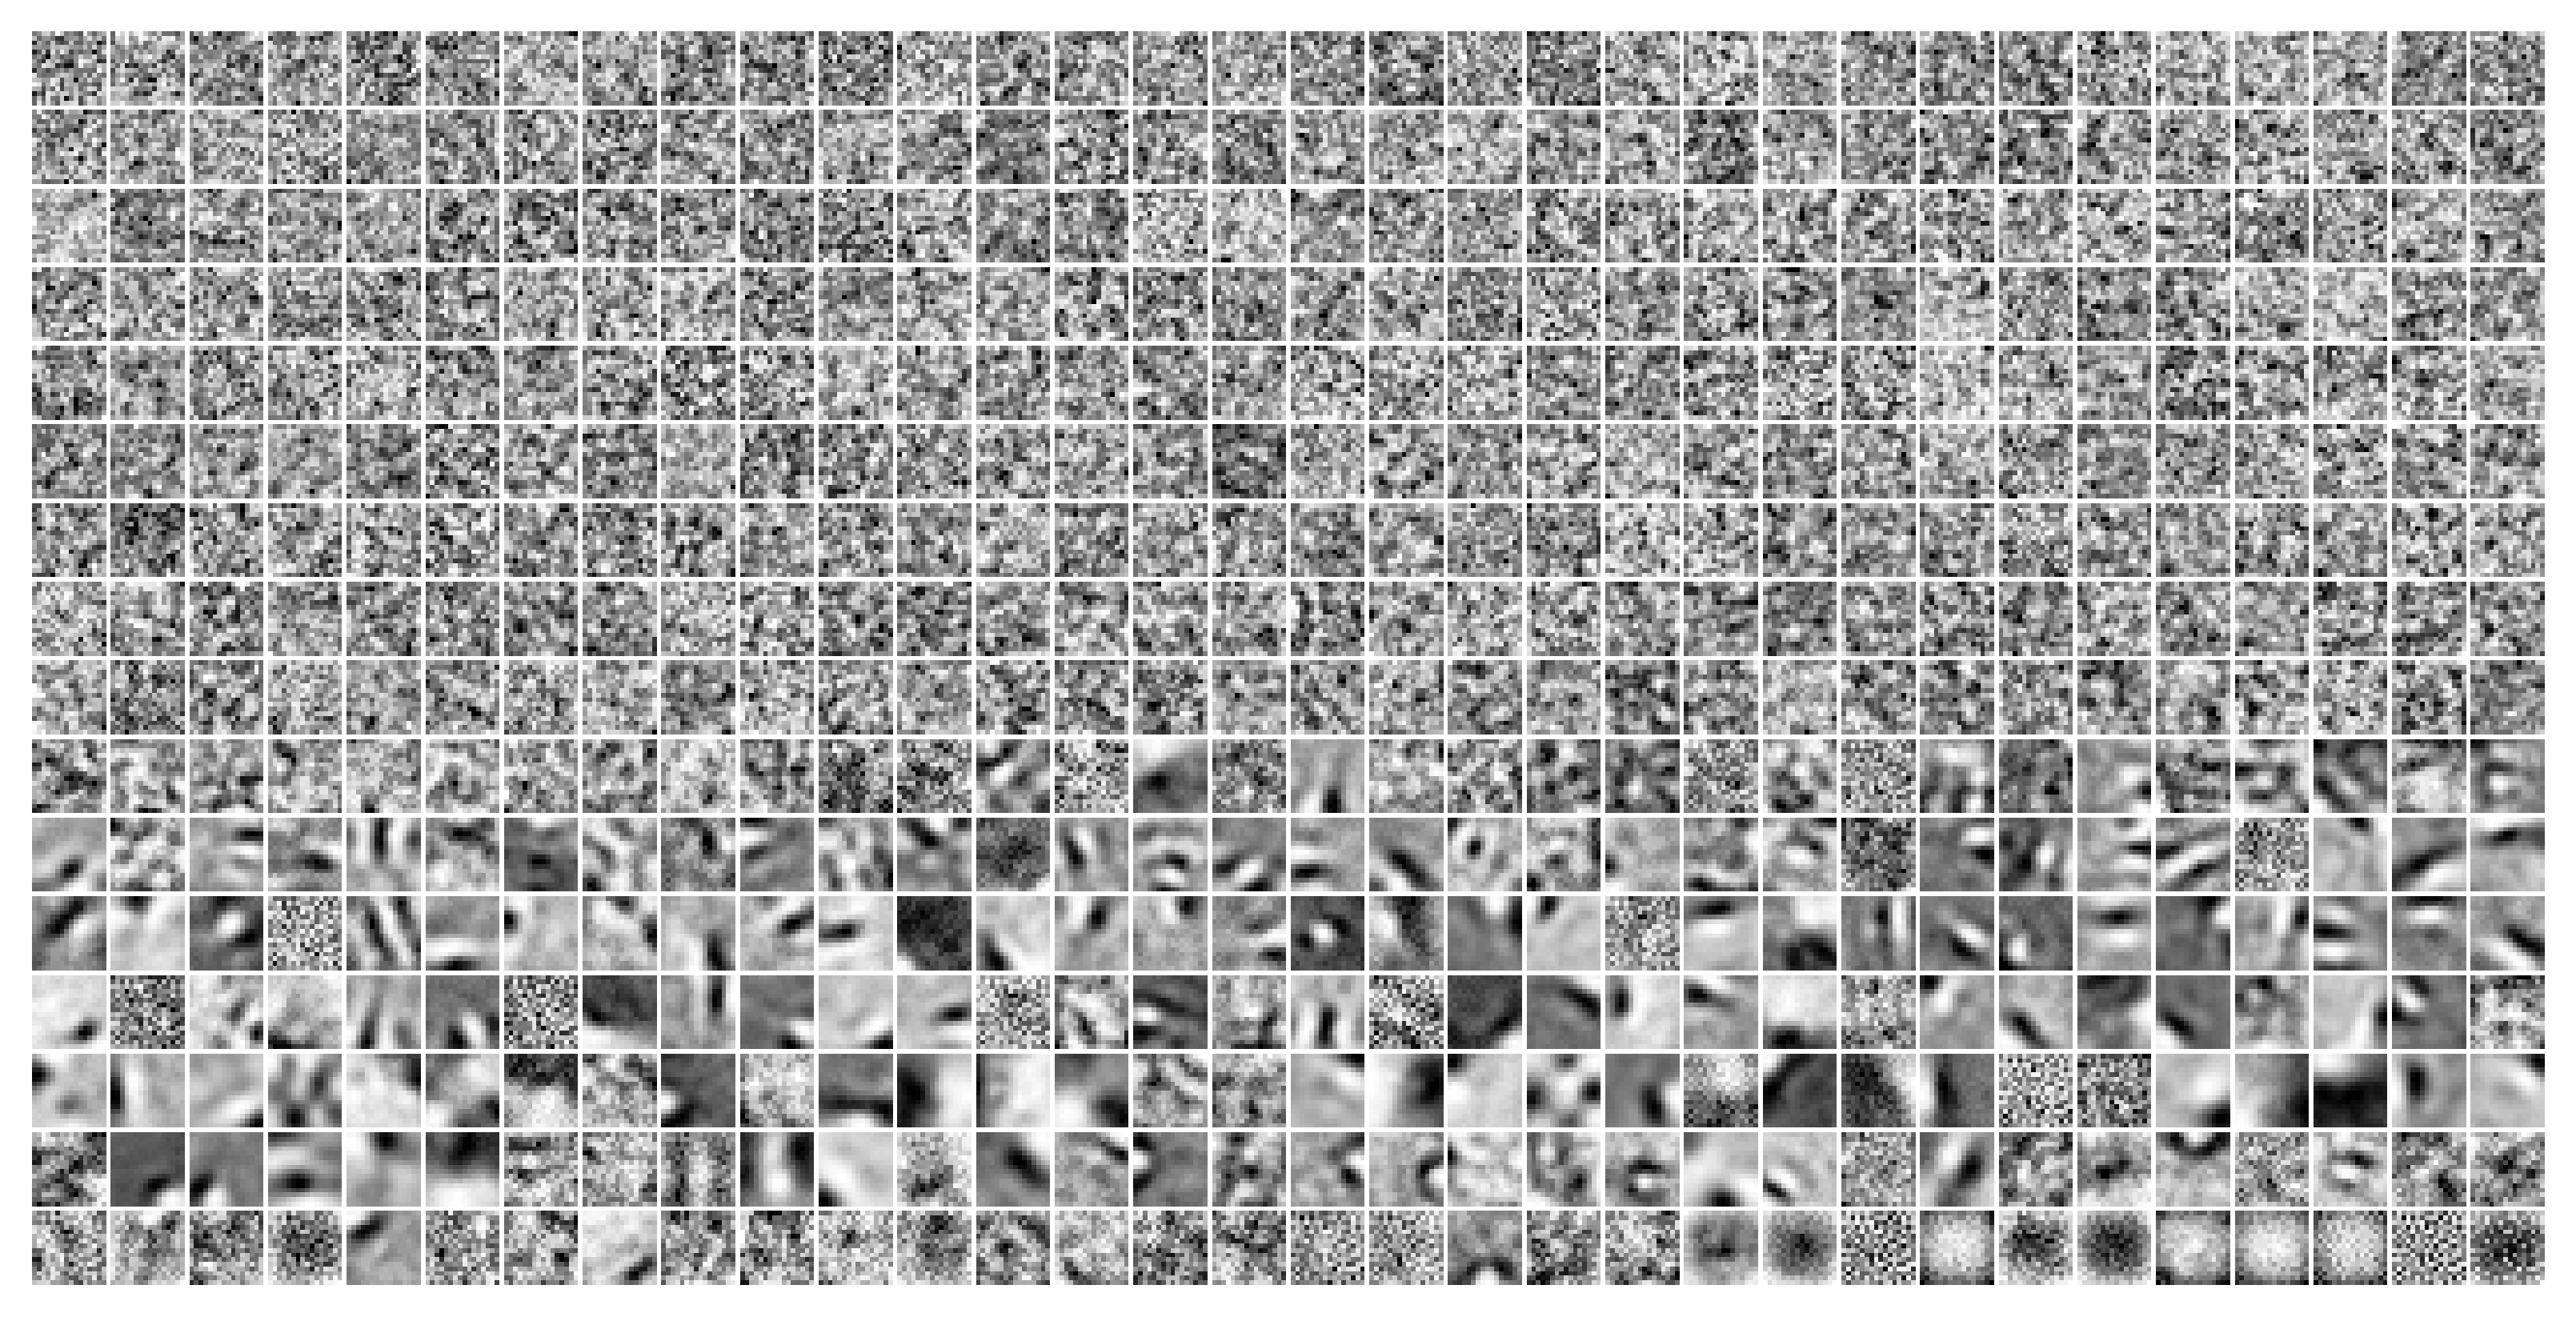

In [10]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))
tr.model.show(order=np.argsort(norms), dpi=400, pad=1);

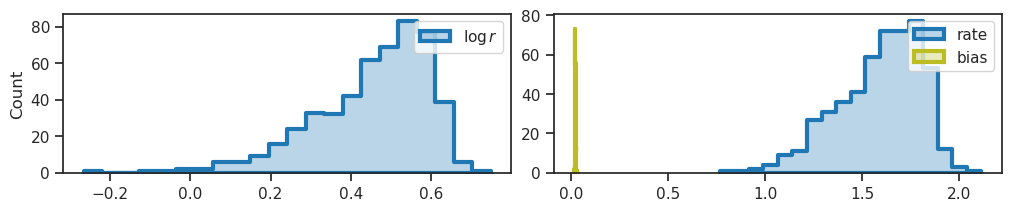

In [19]:
log_rate = tonp(tr.model.layer.u_init[0].squeeze())
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(log_rate, color='C0', element='step', label=r'$\log r$', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(np.exp(log_rate), color='C0', element='step', label='rate', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

In [20]:
dead = (log_rate < -1) | (log_rate > 2)
dead.sum(), (~dead).sum(), dead.sum() / len(dead)

(0, 512, 0.0)

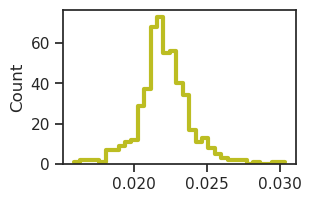

In [21]:
histplot(bias, color='C8', lw=3)
plt.show()

In [22]:
(bias > 0).mean()

1.0

In [23]:
bias[dead]

array([], dtype=float32)

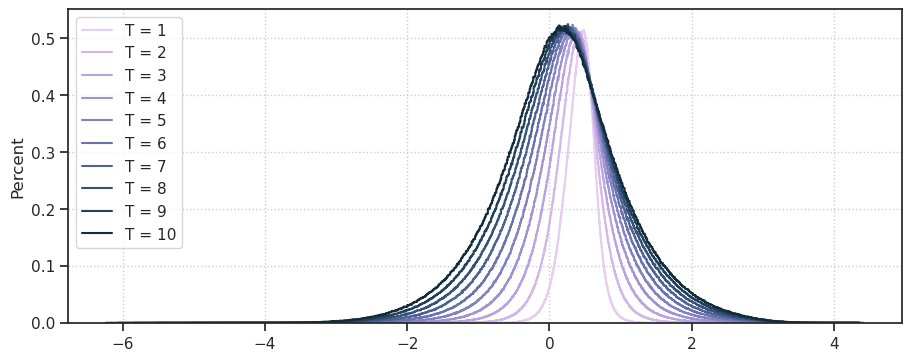

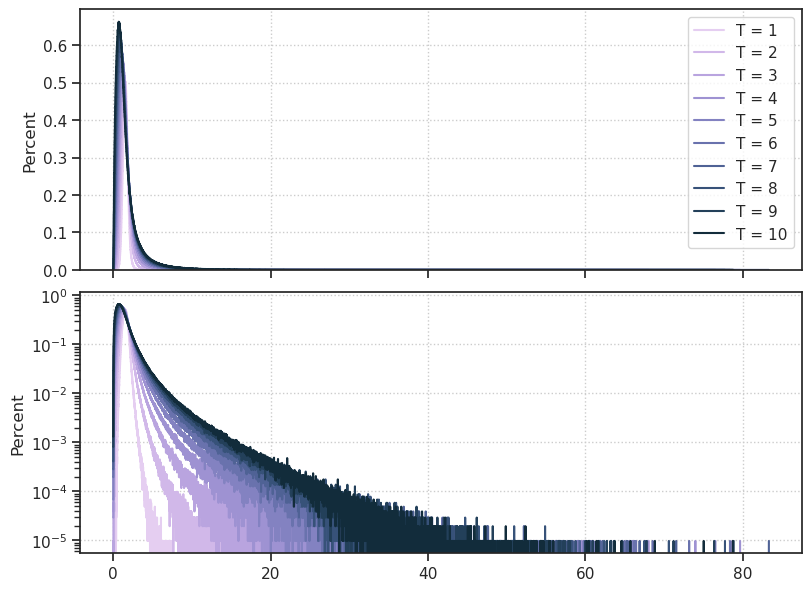

In [25]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [26]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8178323483750889, 0.7228373334284097, 0.9156857084467959],
 [0.7243842279061081, 0.6447757533596252, 0.8762257510361532],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.5137602016853071, 0.5080741960907603, 0.7578471038208457],
 [0.41165859076399486, 0.44819771588937396, 0.6800995692970601],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.2159918198929715, 0.32026582325789205, 0.4738907509899629],
 [0.13614552585465997, 0.2501791993868458, 0.35455980691569594],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

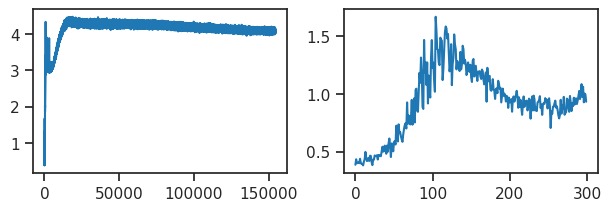

In [27]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [28]:
(grad > 100).sum()

0

100%|█████████████████████████████████| 50/50 [01:40<00:00,  2.01s/it]


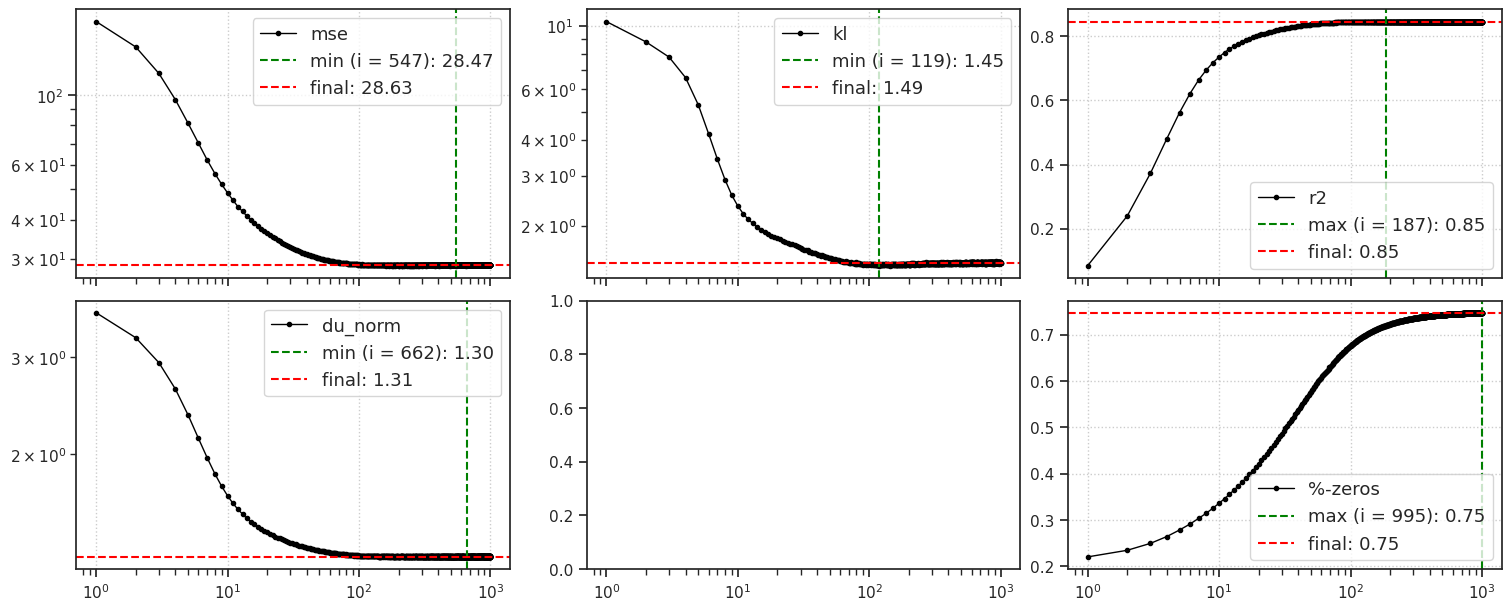

CPU times: user 2min 7s, sys: 3.6 s, total: 2min 11s
Wall time: 2min 11s


In [30]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=50,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')